# No 1. Credit Score Dataset

### goal --> Classification Model XGBoost, Random Forest

Credit Score Dataset:
a.	ID: Unique identification of an entry     
b.	Customer_ID: Unique identification of a person
c.	Month: The month of the year
d.	Name: The name of a person  
e.	Age: The age of the person       
f.	SSN: The social security number of a person
g.	Occupation: The occupation of the person
h.	Annual_Income: The annual income of the person
i.	Monthly_Inhand_Salary: The monthly base salary of a person
j.	Num_Bank_Accounts: The number of bank accounts a person holds
k.	Num_Credit_Card: The number of other credit cards held by a person
l.	Interest_Rate: The interest rate on credit card
m.	Num_of_Loan: The number of loans taken from the bank
n.	Type_of_Loan: The types of loan taken by a person
o.	Delay_from_due_date: The average number of days delayed from the payment date    
p.	Num_of_Delayed_Payment: The average number of payments delayed by a person
q.	Changed_Credit_Limit: The percentage change in credit card limit
r.	Num_Credit_Inquiries: The number of credit card inquiries
s.	Credit_Mix: The classification of the mix of credits
t.	Outstanding_Debt: The remaining debt to be paid (in USD)
u.	Credit_Utilization_Ratio: The utilization ratio of credit card
v.	Credit_History_Age: The age of credit history of the person
w.	Payment_of_Min_Amount: Whether only the minimum amount was paid by the person
x.	Total_EMI_per_month: The monthly EMI payments (in USD)
y.	Amount_invested_monthly: The monthly amount invested by the customer (in USD)
z.	Payment_Behaviour: the payment behavior of the customer (in USD)
aa.	Monthly_Balance: The monthly balance amount of the customer (in USD)
bb.	Credit_Score (target): Represents how trustworthy a person is


### Load Libraries

In [ ]:
#!pip install xgboost

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

### Read Dataset

In [2]:
#df = df.read_csv("Credis_Score_Dataset_A.csv") #ini sebelum melihat format inconsistencies dalam missing values di datanya

In [3]:
MISSING_VALUES = ["_", "-", "", " ", "  ", "na", "n/a", "NA", "N/A", "null", "NULL", "Null", "none", "None", "NONE", "nan", "NaN"]

In [4]:
df = pd.read_csv("Credis_Score_Dataset_A.csv", na_values=MISSING_VALUES, keep_default_na=True)

In [5]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x113fb,CUS_0x78af,February,Greg Roumeliotisg,36,365-11-8309,Teacher,88827.54000000002,7199.295000,5,...,Standard,512.09,27.652902,11 Years and 3 Months,Yes,277.043609,135.02877621323586,!@9#%8,567.8571148175499,Standard
1,0x23e41,CUS_0x7d8,April,Ayla Jeany,14_,680-85-5010,Doctor,19288.47_,1408.372500,10,...,Bad,1873.07,28.477331,5 Years and 7 Months,Yes,49.388699,176.92086141687474,Low_spent_Small_value_payments,204.52768958953004,Poor
2,0x20142,CUS_0x39d4,January,Debra Shermanh,45,034-42-6069,Accountant,73507.4,6146.616667,8,...,Bad,1660.98,24.865827,15 Years and 7 Months,Yes,412.051367,186.58955671354923,High_spent_Medium_value_payments,266.02074289372644,Poor
3,0xd194,CUS_0x8ac8,July,Steve Schererz,22,751-26-7144,Teacher,10037.735,871.477917,8,...,Bad,3052.44,33.704571,8 Years and 1 Months,Yes,36.667662,16.69811395620942,High_spent_Medium_value_payments,283.7820159487275,Standard
4,0x64dc,CUS_0x6734,March,Lefterisi,19,276-02-5954,_______,30922.5,2477.875000,8,...,Bad,4742.53,30.643675,1 Years and 0 Months,Yes,165.891821,218.49777601292416,Low_spent_Small_value_payments,153.39790325798555,Standard


In [6]:
df.shape

(16821, 28)

In [7]:
df.dtypes

,0
ID,object
Customer_ID,object
Month,object
Name,object
Age,object
SSN,object
Occupation,object
Annual_Income,object
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


dataset ini ada 28 variables, majoritas variablesnya berguna untuk membuat model xgboost dan random forest, tetapi beberapa juga tidak diperlukan seperti ID dan Customer_ID, Name, Month. values" ini unik dan tergantung kepada setiap customer/client, mereka hanya identifier dan bukan fitur atau parameter yang akan ber-efek (mengubah atau mempengaruhi) credit score. maka beberapa variables ini di hilangkan aja. SSN adalah social security number yang diberikan kepada permanent residents, and eligible working residents to track income, report taxes, hal ini bisa berhubungan dengan employment, credit checks, banking, and government services, tetapi sejak dalam dataset ini, sudah ada column Occupation, Annual_Income, Monthly_Inhand_Salary, SSN tidak menambahkan informasi baru. SSN berpotensi mengganggu one-hot encoding nanti, memberikannya pola yang tidak asli, ordering yang tidak penting, bisa membuat overfitting. karena datasetnya bisa mempunyai lebih dari 1 record per person, SSN dapat meng-identifikasi orang itu secara unik, dan model berpotensi menghafal incividual dibanding menelaah pola. Month sebenernya bisa useful jika dia kasih tau season spendingnya --> holidays, school fee. tapi itu hanya kalau ada timeseries dalam datanya, bulan tidak berpengaruh kepada credit score

## PreProcessing

In [8]:
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month'])

df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,36,Teacher,88827.54000000002,7199.295000,5,5,7,4,"Mortgage Loan, Mortgage Loan, Auto Loan, and P...",12,...,Standard,512.09,27.652902,11 Years and 3 Months,Yes,277.043609,135.02877621323586,!@9#%8,567.8571148175499,Standard
1,14_,Doctor,19288.47_,1408.372500,10,6,21,6,"Payday Loan, Not Specified, Student Loan, Home...",55,...,Bad,1873.07,28.477331,5 Years and 7 Months,Yes,49.388699,176.92086141687474,Low_spent_Small_value_payments,204.52768958953004,Poor
2,45,Accountant,73507.4,6146.616667,8,220,18,7,"Mortgage Loan, Student Loan, Credit-Builder Lo...",34,...,Bad,1660.98,24.865827,15 Years and 7 Months,Yes,412.051367,186.58955671354923,High_spent_Medium_value_payments,266.02074289372644,Poor
3,22,Teacher,10037.735,871.477917,8,7,30,5,"Mortgage Loan, Mortgage Loan, Not Specified, D...",17,...,Bad,3052.44,33.704571,8 Years and 1 Months,Yes,36.667662,16.69811395620942,High_spent_Medium_value_payments,283.7820159487275,Standard
4,19,_______,30922.5,2477.875000,8,8,1028,9,"Auto Loan, Payday Loan, Not Specified, Persona...",57,...,Bad,4742.53,30.643675,1 Years and 0 Months,Yes,165.891821,218.49777601292416,Low_spent_Small_value_payments,153.39790325798555,Standard


In [9]:
df.info

<bound method DataFrame.info of        Age     Occupation      Annual_Income  Monthly_Inhand_Salary  \
0       36        Teacher  88827.54000000002            7199.295000   
1      14_         Doctor          19288.47_            1408.372500   
2       45     Accountant            73507.4            6146.616667   
3       22        Teacher          10037.735             871.477917   
4       19        _______            30922.5            2477.875000   
...    ...            ...                ...                    ...   
16816   29      Developer           34378.87                    NaN   
16817   48       Engineer           34053.28            2782.773333   
16818   29     Journalist           9869.175             536.431250   
16819   51  Media_Manager           85471.89            7179.657500   
16820   27         Writer           20373.24            1845.770000   

       Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan  \
0                      5                5              7           4   
1                     10                6             21           6   
2                      8              220             18           7   
3                      8                7             30           5   
4                      8                8           1028           9   
...                  ...              ...            ...         ...   
16816                  6                5              6           0   
16817                  3                6              5           3   
16818                  7                7             19           0   
16819                  4                5              3           0   
16820                  4                6             21           2   

                                            Type_of_Loan  Delay_from_due_date  \
0      Mortgage Loan, Mortgage Loan, Auto Loan, and P...                   12   
1      Payday Loan, Not Specified, Student Loan, Home...                   55   
2      Mortgage Loan, Student Loan, Credit-Builder Lo...                   34   
3      Mortgage Loan, Mortgage Loan, Not Specified, D...                   17   
4      Auto Loan, Payday Loan, Not Specified, Persona...                   57   
...                                                  ...                  ...   
16816                                                NaN                    5   
16817  Debt Consolidation Loan, Credit-Builder Loan, ...                    1   
16818                                                NaN                   15   
16819                                                NaN                   11   
16820             Credit-Builder Loan, and Not Specified                   16   

       ... Credit_Mix  Outstanding_Debt  Credit_Utilization_Ratio  \
0      ...   Standard            512.09                 27.652902   
1      ...        Bad           1873.07                 28.477331   
2      ...        Bad           1660.98                 24.865827   
3      ...        Bad           3052.44                 33.704571   
4      ...        Bad           4742.53                 30.643675   
...    ...        ...               ...                       ...   
16816  ...   Standard           1020.66                 29.651881   
16817  ...       Good           1033.06                 30.436727   
16818  ...        NaN            274.65                 37.668342   
16819  ...        NaN            232.67                 39.135661   
16820  ...   Standard           1517.43                 26.091942   

          Credit_History_Age Payment_of_Min_Amount  Total_EMI_per_month  \
0      11 Years and 3 Months                   Yes           277.043609   
1       5 Years and 7 Months                   Yes            49.388699   
2      15 Years and 7 Months                   Yes           412.051367   
3       8 Years and 1 Months                   Yes            36.667662   
4       1 Years and 0 Months                   Yes           165.891821  

In [10]:
df.describe(include="all")

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,16821,16821,16821,14254.000000,16821.000000,16821.000000,16821.000000,16821,14911,16821.000000,...,13359,16821,16821.000000,15331,16821,16821.000000,16041,16820,16603,16820
unique,384,16,10557,NaN,NaN,NaN,NaN,98,4998,NaN,...,3,9612,NaN,403,3,NaN,15269,7,16603,3
top,26,_______,27983.07,NaN,NaN,NaN,NaN,3,Debt Consolidation Loan,NaN,...,Standard,1433.89,NaN,17 Years and 8 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,830.7357115487342,Standard
freq,495,1257,6,NaN,NaN,NaN,NaN,2447,217,NaN,...,6215,9,NaN,85,8957,NaN,743,4327,1,8991
mean,NaN,NaN,NaN,4166.400135,17.499138,22.072885,67.512871,NaN,NaN,21.065038,...,NaN,NaN,32.248778,NaN,NaN,1386.123605,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,3167.847576,118.804110,128.851471,446.568618,NaN,NaN,14.790770,...,NaN,NaN,5.125734,NaN,NaN,8360.417113,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,303.645417,-1.000000,0.000000,1.000000,NaN,NaN,-5.000000,...,NaN,NaN,20.172942,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1622.001667,3.000000,4.000000,8.000000,NaN,NaN,10.000000,...,NaN,NaN,27.972757,NaN,NaN,30.635718,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,3055.784583,6.000000,6.000000,14.000000,NaN,NaN,18.000000,...,NaN,NaN,32.284010,NaN,NaN,69.888275,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,5912.644583,8.000000,7.000000,20.000000,NaN,NaN,28.000000,...,NaN,NaN,36.459488,NaN,NaN,161.978219,NaN,NaN,NaN,NaN


In [70]:
#cek duplicate values
df.duplicated().sum()
#no duplicated values --> nice

np.int64(0)

di sini keliatan ada inconsistent values di SSN, inconsistent atau invalid values di SSN, lebih baik di NULL-in

In [12]:
#cek unique values, karena ada index, automatis setiap row unique, cek uniqueness in column per variabelnya

df.index.name
unique_counts = df.nunique().sort_values(ascending = False)
unique_counts

#dataset ini banyak sekali unique valuesnya

,0
Credit_Utilization_Ratio,16821
Monthly_Balance,16603
Amount_invested_monthly,15269
Annual_Income,10557
Outstanding_Debt,9612
Total_EMI_per_month,9128
Monthly_Inhand_Salary,8993
Type_of_Loan,4998
Changed_Credit_Limit,3070
Credit_History_Age,403


In [13]:
#cek unique values buat categorical column

cat_cols = df.select_dtypes(include=["object", "bool"]).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())

#dari hasilnya --> banyak sekali salah formatting dan inconsistent values di datanya
# fix per columns


Column: Age
['36' '14_' '45' '22' '19' '26' '43' '56' '49' '39' '18' '44' '16' '28'
 '37' '33' '32_' '34' '21' '41' '32' '25' '38' '27' '53' '29' '14' '22_'
 '30' '55' '40' '-500' '20' '18_' '35' '31' '23' '48' '52' '4536' '24'
 '42' '40_' '19_' '41_' '50' '46' '38_' '15' '2181' '51' '2160' '47' '24_'
 '8442' '4177' '5970' '17' '33_' '31_' '21_' '54' '35_' '118' '29_' '45_'
 '3213' '30_' '27_' '4781' '15_' '20_' '34_' '49_' '4670' '5479' '28_'
 '4575' '3601' '36_' '52_' '23_' '1355' '306' '3319' '53_' '50_' '2090'
 '2076' '44_' '55_' '1006' '4556' '5478' '4383_' '46_' '16_' '5939' '54_'
 '3452' '25_' '1366' '2580' '4298' '42_' '6394' '1812' '5147' '2840' '47_'
 '4944' '7349' '3553' '3244' '4050' '5897' '7377' '6943' '2305' '1443'
 '4227' '37_' '51_' '8173' '7042' '48_' '4710' '6184' '43_' '5165' '3264'
 '1095' '6364' '8150' '26_' '2178' '3750' '3861' '4847' '6843' '7438'
 '3806' '2455' '651' '6725' '7973' '6736' '7414' '7527' '6395' '5426'
 '6962_' '5524' '4583_' '7493' '3205' '5748' 

In [14]:
#FIX INCONSISTENCIES


#ini semua variabel yang seharusnya numeric, tapi terkadang ada leading/lagging "_",
#jadi beberapa masih object, maka gabisa langsung select dtypes(["object", "bool"]) atau "int64" dan "float64"

numeric_columns = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_columns:
    df[col] = (
        df[col] #fix dulu semua yang disini string agar bisa detect adanya "_" dan diganti
        .astype(str)
        .str.replace(r"[^0-9.\-]", "", regex=True) # detect semua di stringnya yang bukan digit, ., atau - sebagai invalid, jadi ""
        .replace("", np.nan) #kalau stringnya kosong abis di remove unique characternya maka di bikin missing value aja
        .astype(float) #ubah datatype yang sudah tidak ada inconsistencies jadi float --> sudah bener data numerik
    )

In [15]:
df.dtypes

,0
Age,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,float64
Num_of_Loan,float64
Type_of_Loan,object
Delay_from_due_date,float64


In [16]:
fixed_cols = df.select_dtypes(include=["float64"]).columns #cek dari yang kita udah ganti semua --> yang akhirnya data type float64

for col in fixed_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Age
[  36.   14.   45.   22.   19.   26.   43.   56.   49.   39.   18.   44.
   16.   28.   37.   33.   32.   34.   21.   41.   25.   38.   27.   53.
   29.   30.   55.   40. -500.   20.   35.   31.   23.   48.   52. 4536.
   24.   42.   50.   46.   15. 2181.   51. 2160.   47. 8442. 4177. 5970.
   17.   54.  118. 3213. 4781. 4670. 5479. 4575. 3601. 1355.  306. 3319.
 2090. 2076. 1006. 4556. 5478. 4383. 5939. 3452. 1366. 2580. 4298. 6394.
 1812. 5147. 2840. 4944. 7349. 3553. 3244. 4050. 5897. 7377. 6943. 2305.
 1443. 4227. 8173. 7042. 4710. 6184. 5165. 3264. 1095. 6364. 8150. 2178.
 3750. 3861. 4847. 6843. 7438. 3806. 2455.  651. 6725. 7973. 6736. 7414.
 7527. 6395. 5426. 6962. 5524. 4583. 7493. 3205. 5748. 1695. 2875. 5840.
 7851. 5579. 5413. 2400. 5784. 1985. 4494. 5906. 8666. 6894. 5340. 3450.
 6426. 6704. 4841. 1808. 3930.  952. 6577. 5361. 4580. 6971. 1300.  381.
 7122. 8155. 1220.  372. 6765. 4649.  240. 4921. 8091. 8124. 2636. 3155.
 6331. 6408. 1452. 5507. 7016. 4448. 4

setelah diperbaiki adanya "_", atau character invalid lainnya, age ada "." di paling belakang nilainya --> ini harmless karena setelah di fix di atas, tipe data yang di delclare adalah float, . itu merepresentasikan decimal di floatnya jadi umur 36. --> 36.0.
ISSUE sekarang ada di invalid values --> age = 2128, 8442
number of bank accounts nggak mungkin juga sampai ribuan --> itu nanti diganti nan aja dan di inpute dengan median --> tidak sensitive terhadap skewed data
number of credit cards punya masalah yang sama dengan number of bank accounts

In [17]:
#sekarang kita bikin validating conditionnya

df.loc[(df["Age"] <= 18) | (df["Age"] >= 100), "Age"] = np.nan #age yang paling make sense buat punya credit card, punya bank acc itu 18
#dan age biasanya kurang dari 100 yang masih membutuhkan credit score secara aktif

df.loc[(df["Num_Bank_Accounts"] <= 0) | (df["Num_Bank_Accounts"] >= 15), "Num_Bank_Accounts"] = np.nan #number of bank acc kita limit jadi 15

df.loc[(df["Num_Credit_Card"] <= 0) | (df["Num_Credit_Card"] >= 10), "Num_Credit_Card"] = np.nan #number of credit cards kita limit max 10


In [18]:
#cek lagi
fixed_cols = df.select_dtypes(include=["float64"]).columns #cek dari yang kita udah ganti semua --> yang akhirnya data type float64

for col in fixed_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Age
[36. nan 45. 22. 19. 26. 43. 56. 49. 39. 44. 28. 37. 33. 32. 34. 21. 41.
 25. 38. 27. 53. 29. 30. 55. 40. 20. 35. 31. 23. 48. 52. 24. 42. 50. 46.
 51. 47. 54.]

Column: Annual_Income
[88827.54 19288.47 73507.4  ... 10629.93 67556.8  64752.4 ]

Column: Monthly_Inhand_Salary
[7199.295      1408.3725     6146.61666667 ... 8529.1825     5652.03333333
 1845.77      ]

Column: Num_Bank_Accounts
[ 5. 10.  8.  7.  1.  9.  4.  3.  6. nan  2.]

Column: Num_Credit_Card
[ 5.  6. nan  7.  8.  4.  9.  1.  3.  2.]

Column: Interest_Rate
[7.000e+00 2.100e+01 1.800e+01 3.000e+01 1.028e+03 1.500e+01 3.200e+01
 1.700e+01 1.100e+01 6.000e+00 1.300e+01 5.000e+00 2.900e+01 9.000e+00
 1.600e+01 8.000e+00 1.200e+01 1.000e+00 1.900e+01 2.000e+01 1.000e+01
 2.377e+03 2.300e+01 2.400e+01 3.000e+00 2.200e+01 2.800e+01 3.300e+01
 4.000e+00 1.400e+01 2.700e+01 2.600e+01 3.238e+03 3.100e+01 2.500e+01
 2.000e+00 1.106e+03 4.263e+03 6.390e+02 3.400e+01 4.884e+03 2.634e+03
 5.474e+03 3.770e+02 3.862e+03 5.

In [19]:
#sekarang kita liat column object
fixed_cols = df.select_dtypes(include=["object"]).columns #cek dari yang kita udah ganti semua --> yang akhirnya data type float64

for col in fixed_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Occupation
['Teacher' 'Doctor' 'Accountant' '_______' 'Writer' 'Musician' 'Engineer'
 'Architect' 'Journalist' 'Entrepreneur' 'Developer' 'Media_Manager'
 'Scientist' 'Manager' 'Lawyer' 'Mechanic']

Column: Type_of_Loan
['Mortgage Loan, Mortgage Loan, Auto Loan, and Payday Loan'
 'Payday Loan, Not Specified, Student Loan, Home Equity Loan, Debt Consolidation Loan, and Not Specified'
 'Mortgage Loan, Student Loan, Credit-Builder Loan, Personal Loan, Auto Loan, Auto Loan, and Auto Loan'
 ... 'Student Loan, Student Loan, Payday Loan, and Payday Loan'
 'Payday Loan, Payday Loan, and Personal Loan'
 'Credit-Builder Loan, Payday Loan, Debt Consolidation Loan, Auto Loan, Auto Loan, and Home Equity Loan']

Column: Credit_Mix
['Standard' 'Bad' nan 'Good']

Column: Credit_History_Age
['11 Years and 3 Months' '5 Years and 7 Months' '15 Years and 7 Months'
 '8 Years and 1 Months' '1 Years and 0 Months' '11 Years and 9 Months' nan
 '18 Years and 10 Months' '16 Years and 1 Months' '8 Years 

dalam column object banyak yang invalid --> dalam occupation ada ______ --> ganti jadi nan


type of loan ditulis sebagai list --> multivalue tapi seperated by "," atau "and"


untuk bikin model yang stabil type of loan mungkin bisa diganti sebagai number of loans aja --> misalnya


Mortgage Loan, Mortgage Loan, Auto Loan, and Payday Loan -> 4


credit history age ditulis sebagai __ years and __ months --> ganti jadi numerik aja as months --> tahun * 12


payment of min amount  = ada NM --> not mentioned min amountnya for now kita bikin nan dulu, nanti di impute pake mode


payment behaviour --> ada invalid string !@9#%8

In [20]:
df["Occupation"] = df["Occupation"].replace("_______", np.nan) #occupation remove spesifik yang _______

df["Num_Loans"] = df["Type_of_Loan"].str.count(",") + 1 #ini dari banyak type of loans di listnya
#kita ubah menjadi data numerical --> ada berapa loans

credit_history_months = [] #dari credit history age yang ada Years and Months, kita ubah jadi
#data numerical --> number of monthsnya aja yang disimpan

for x in df["Credit_History_Age"]:
    if pd.isna(x):
        credit_history_months.append(np.nan)
    else:
        years, months = x.split(" Years and ")
        months = months.replace(" Months", "")
        total_months = int(years) * 12 + int(months)
        credit_history_months.append(total_months)

df["Credit_History_Age_Months"] = credit_history_months
df.drop(columns="Credit_History_Age", inplace=True) #di drop karena ga perlu lagi, sudah di jadiin months

df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", np.nan)

df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan) #replace spesifik string yg ada

In [21]:
# cek lagi

fixed_cols = df.select_dtypes(include=["object"]).columns #cek dari yang kita udah ganti semua --> yang akhirnya data type float64

for col in fixed_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Occupation
['Teacher' 'Doctor' 'Accountant' nan 'Writer' 'Musician' 'Engineer'
 'Architect' 'Journalist' 'Entrepreneur' 'Developer' 'Media_Manager'
 'Scientist' 'Manager' 'Lawyer' 'Mechanic']

Column: Type_of_Loan
['Mortgage Loan, Mortgage Loan, Auto Loan, and Payday Loan'
 'Payday Loan, Not Specified, Student Loan, Home Equity Loan, Debt Consolidation Loan, and Not Specified'
 'Mortgage Loan, Student Loan, Credit-Builder Loan, Personal Loan, Auto Loan, Auto Loan, and Auto Loan'
 ... 'Student Loan, Student Loan, Payday Loan, and Payday Loan'
 'Payday Loan, Payday Loan, and Personal Loan'
 'Credit-Builder Loan, Payday Loan, Debt Consolidation Loan, Auto Loan, Auto Loan, and Home Equity Loan']

Column: Credit_Mix
['Standard' 'Bad' nan 'Good']

Column: Payment_of_Min_Amount
['Yes' 'No' nan]

Column: Payment_Behaviour
[nan 'Low_spent_Small_value_payments' 'High_spent_Medium_value_payments'
 'Low_spent_Medium_value_payments' 'High_spent_Small_value_payments'
 'Low_spent_Large_value

In [22]:
df.dtypes #di akhirnya ada kolumn baru Credit_History_Age_Months --> itu yang tadi credit history age diganti jadi months aja

,0
Age,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,float64
Num_of_Loan,float64
Type_of_Loan,object
Delay_from_due_date,float64


In [23]:
#sekarang handle missing values & outliers(numerical)
# numerical --> impute dengan median --> not sensitive to skewed data
#categorical --> impute dengan mode

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
missing = df.isna().sum().sort_values(ascending=False)
missing

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,0
Delay_from_due_date,0


### Kesimpulan Preprocessing

DUPLICATED VALUES:

none found


UNIQUE VALUES (more details in the code block comments)
- age inconsistent & invalid
- num of loan tidak valid & inconsistent
hampir semua categorical columns tidak consistent
- monthly balance & credit score aman

fixing inconsistencies dengan str lower, regexp dan strip untuk whitespace, inconsistent capitalisation sama unique, invalid values dengan regexp

credit history age --> changed to credit history months agar ngga ada "Years and Months" dan sekarang data numeric

- age column yang ada values negatif juga di limit ke reasonable range 18 - 100 dan yang tidak temasuk akan di buat nan
- number of bank accounts limit ke 15, yang lain dibuat nan . it doesnt make sense for some of it to be in thousands
- number of credit cards limit ke 10, yang lain dibuat nan

OUTLIERS & MISSING VALUES

Numerical:
- impute outliers & missing values dengan median (not sensitive to skewed data)
- keep extreme values --> still valuable data

Categorical:
- impute dengan mode

### Visualisation

In [71]:
#karena credit score itu object --> kita label encode itu dulu
le = LabelEncoder()
df["Credit_Score_Num"] = le.fit_transform(df["Credit_Score"])

In [26]:
df[["Credit_Score", "Credit_Score_Num"]].head()

,Credit_Score,Credit_Score_Num
0,Standard,2
1,Poor,1
2,Poor,1
3,Standard,2
4,Standard,2


In [27]:
num_df = df.select_dtypes(include=["int64", "float64"])

In [28]:
"Credit_Score_Num" in num_df.columns

True

In [29]:
df["Credit_Score_Num"].dtype

dtype('int64')

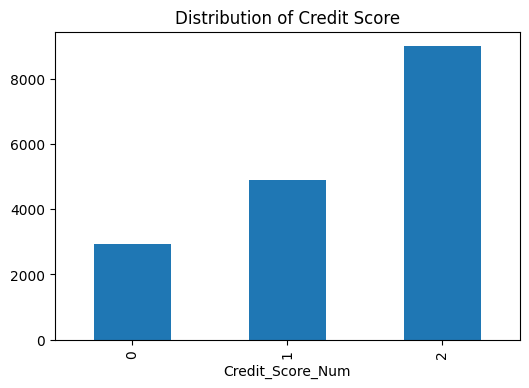

In [30]:
#cek distribusi dari credit scores --> bisa pake count

counts = df["Credit_Score_Num"].value_counts().sort_index()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Distribution of Credit Score")
plt.show()

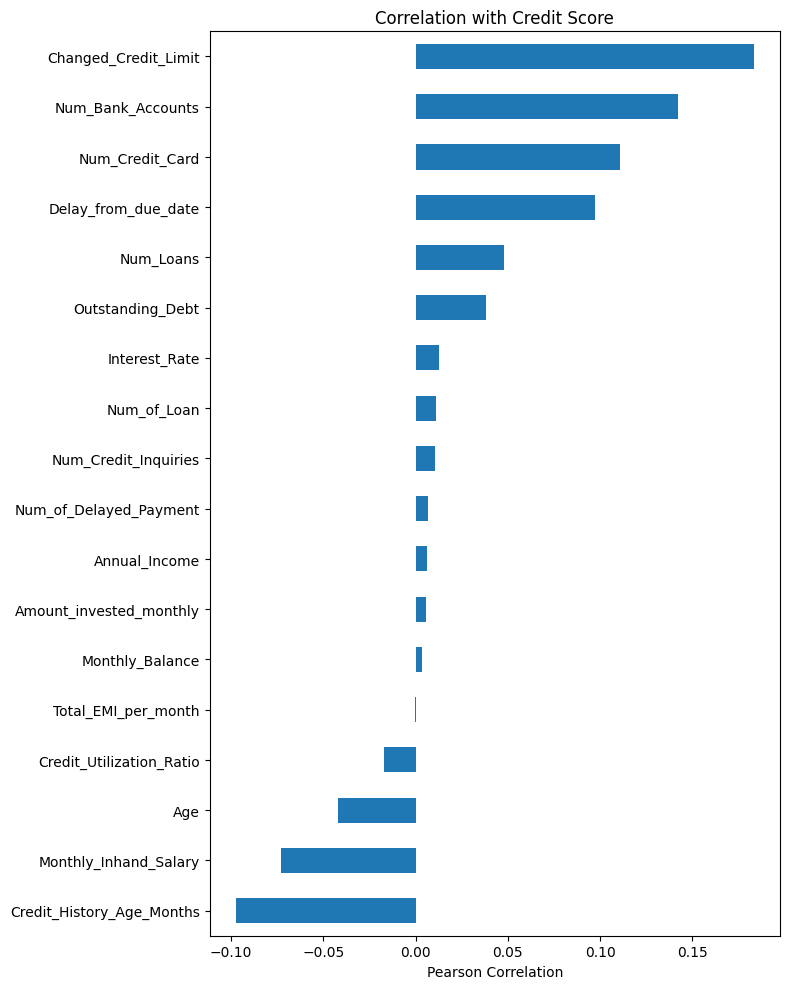

In [31]:
# bikin correlation plot antara semua variables dengan target variable = credit score

num_df = df.select_dtypes(include=[np.number])

corr = (
    num_df.corr()["Credit_Score_Num"]
    .drop("Credit_Score_Num")
    .sort_values())

plt.figure(figsize=(8, 10))
corr.plot(kind="barh")
plt.title("Correlation with Credit Score")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

#paling kuat overall --> changed credit limit
# secara general korelasi tidak terlalu kuat --> ngga ada yang diatas 0.5

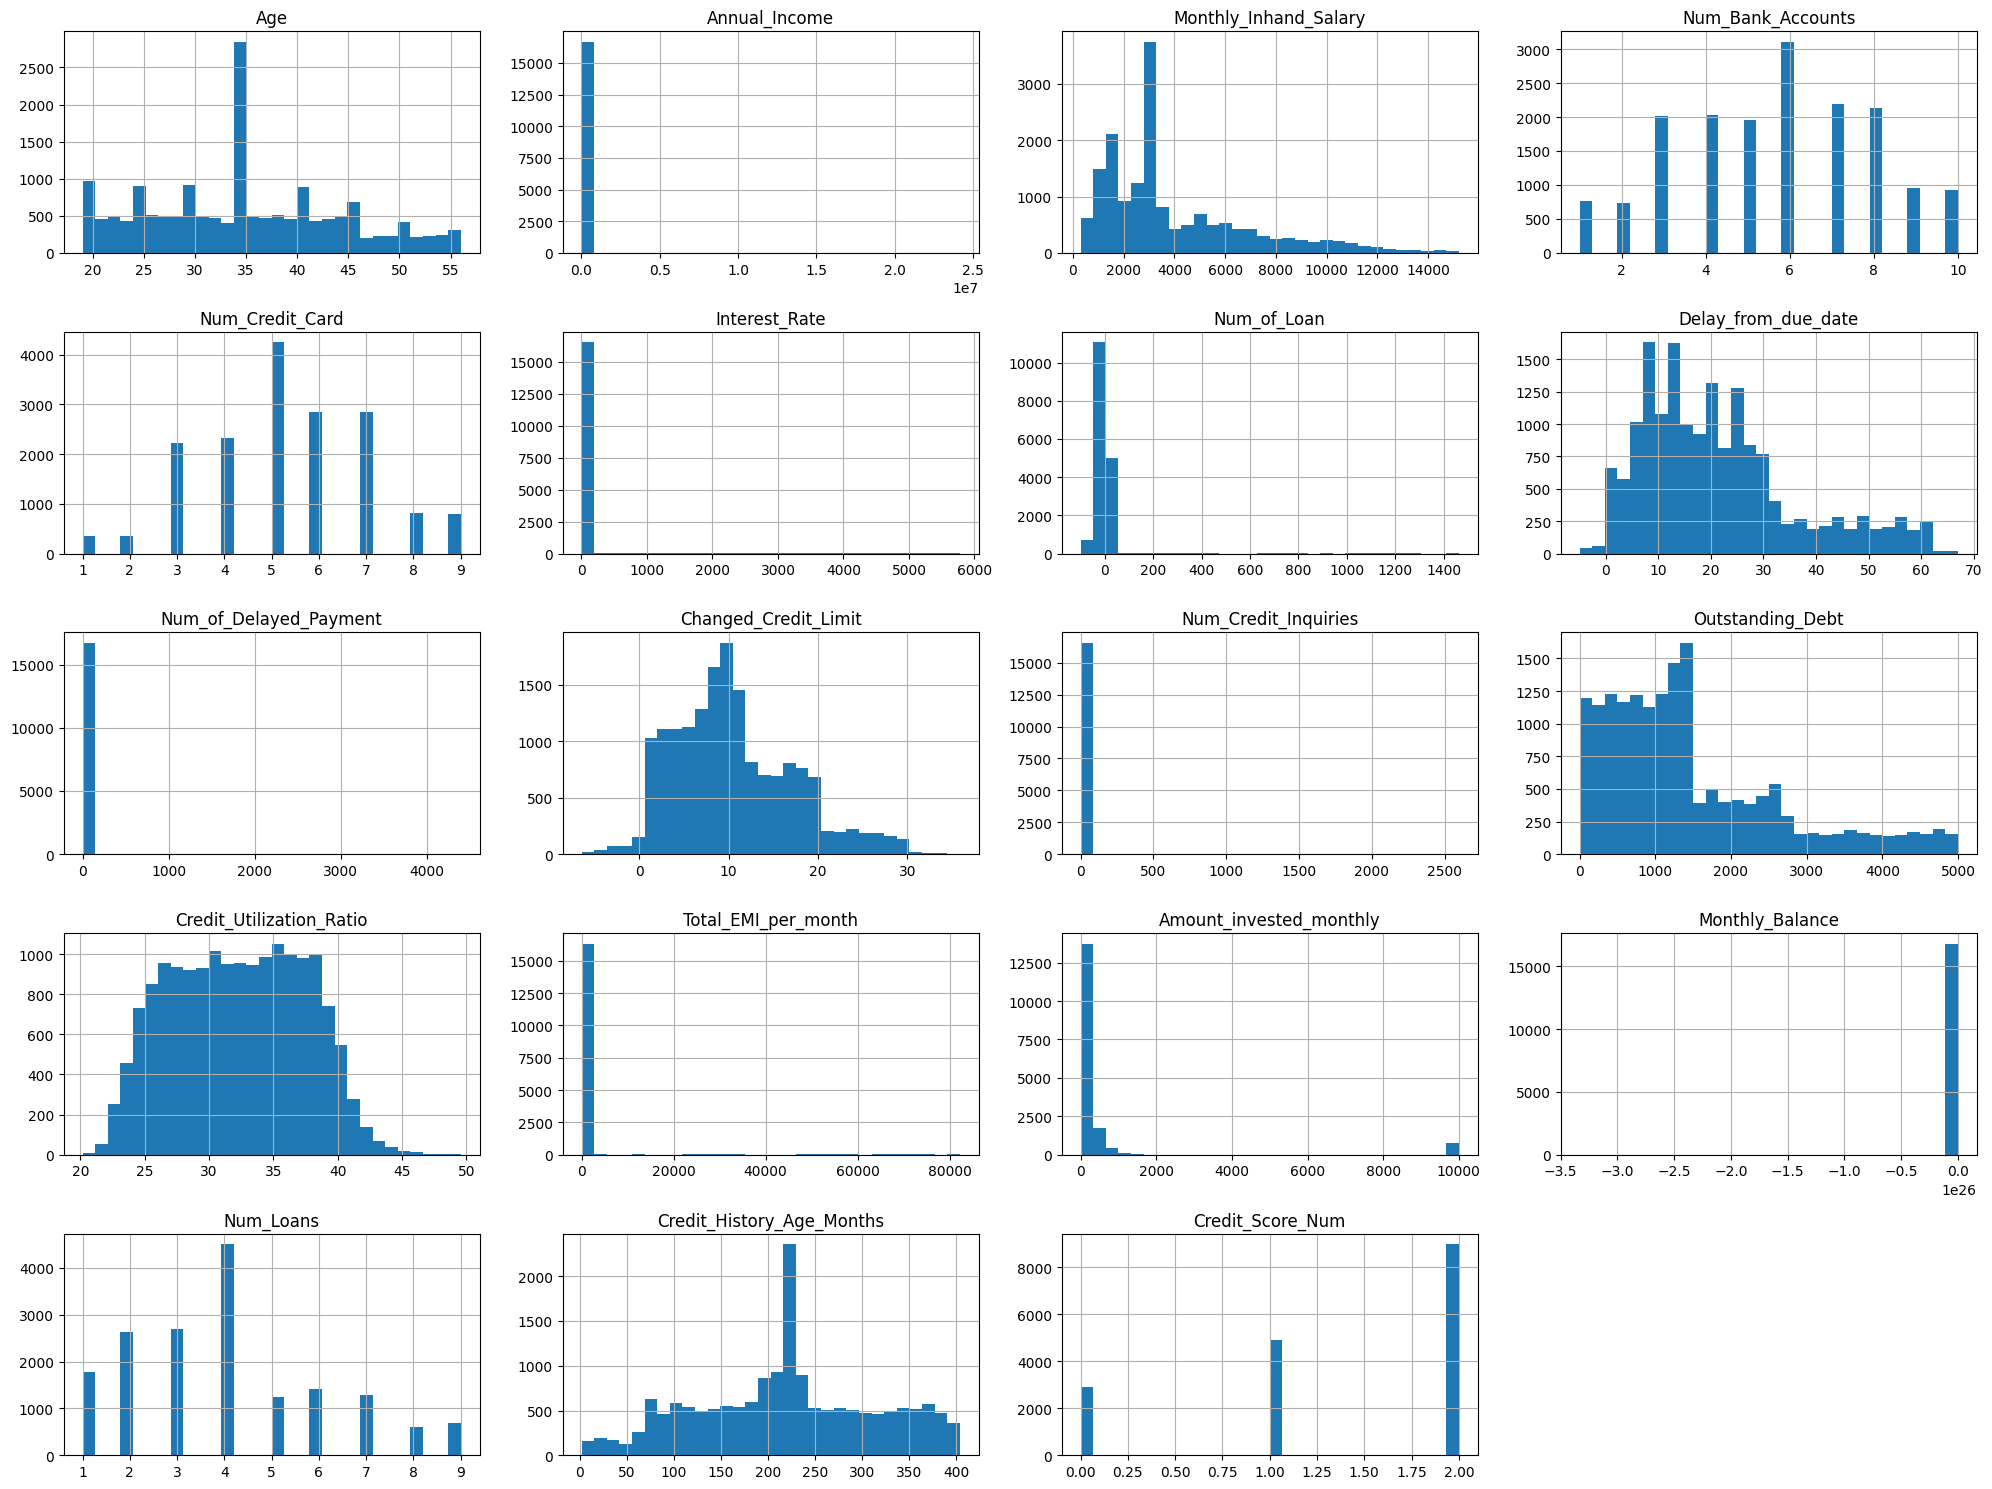

In [72]:
#distribusi dari semua numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64", "int32"]).columns

df[numeric_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

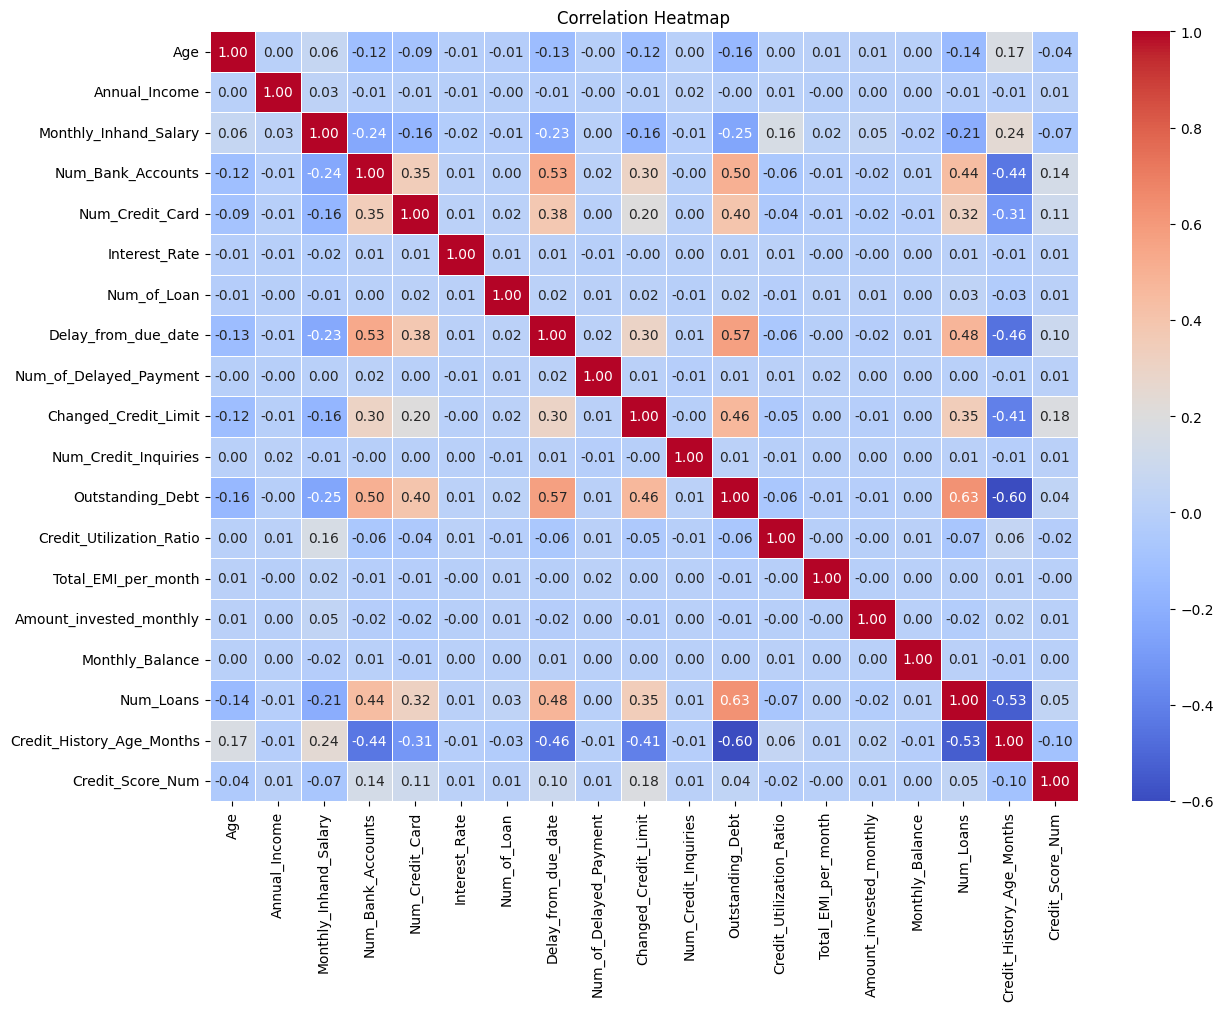

In [33]:
import seaborn as sns

plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".2f",)
plt.title("Correlation Heatmap")
plt.show()

#korelasi antar fitur"

### Kesimpulan EDA

Label Encoding Credit Score --> Credit Score Num
agar data numerical dan lebih mudah di handle untuk korelasi dan model nanti

0 = good

1 = poor

2 = standard

Distribusi Credit Score

right skewed --> credit score num 2 = Standard


Korrelasi fitur dengan Credit Score:

very strong positive corr:
- changed credit limit
- num bank accounts
- num credit cards

Very strong negative corr:
- credit history age months
- monthly inhand salary
- age

### Bikin Model XGBoost & Random Forest

In [34]:
df.dtypes

,0
Age,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,float64
Num_Credit_Card,float64
Interest_Rate,float64
Num_of_Loan,float64
Type_of_Loan,object
Delay_from_due_date,float64


In [35]:
X = df.drop(columns=["Credit_Score", "Credit_Score_Num"]) # indeoendent values --> semua yg ngga target variables jadi feature
y = df["Credit_Score_Num"] #ini target variablesnya

In [36]:
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#### RANDOM FOREST

In [49]:
rf = RandomForestClassifier(random_state=42)

In [50]:
rf_pipeline = Pipeline(steps=[("preprocess", preprocessor),("model", rf)])

In [51]:
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
}


#sebenernya berniat pake gridsearch, tapi pas di run laptop aku crash terus
#RandomSearch
#pros: tidak computationally expensive
# cons: tidak mencoba semua kombinasi fitur dengan target

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    n_jobs=2,
    random_state=42
)

In [73]:
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

#### XGBOOST

In [58]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)

In [59]:
xgb_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", xgb)])


In [60]:
xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
}

In [68]:
xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_params,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

In [69]:
xgb_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:02:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt',...
                                                            max_delta_step=None,
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_class=3, ...))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [63]:
xgb_best = xgb_search.best_estimator_

### Analyze Model Performance

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#random forst
y_pred_rf = rf_best.predict(X_test)

#xgboost
y_pred_xgb = xgb_best.predict(X_test)


def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision (weighted):", precision_score(y_true, y_pred, average='weighted'))
    print("Recall (weighted):", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score (weighted):", f1_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

#panggil function untuk display nilai" confusion matrix
evaluate_model(y_test, y_pred_rf, "Random Forest")

evaluate_model(y_test, y_pred_xgb, "XGBoost")


--- Random Forest Evaluation ---
Accuracy: 0.7016344725111441
Precision (weighted): 0.7001925366023631
Recall (weighted): 0.7016344725111441
F1-score (weighted): 0.7002103666129436

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.54      0.55       585
           1       0.73      0.68      0.71       981
           2       0.72      0.77      0.74      1799

    accuracy                           0.70      3365
   macro avg       0.68      0.66      0.67      3365
weighted avg       0.70      0.70      0.70      3365

--- XGBoost Evaluation ---
Accuracy: 0.7049034175334324
Precision (weighted): 0.7053856345264442
Recall (weighted): 0.7049034175334324
F1-score (weighted): 0.7046125937082103

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60       585
           1       0.73      0.67      0.70       981
           2       0.73      0.76      0.74      1

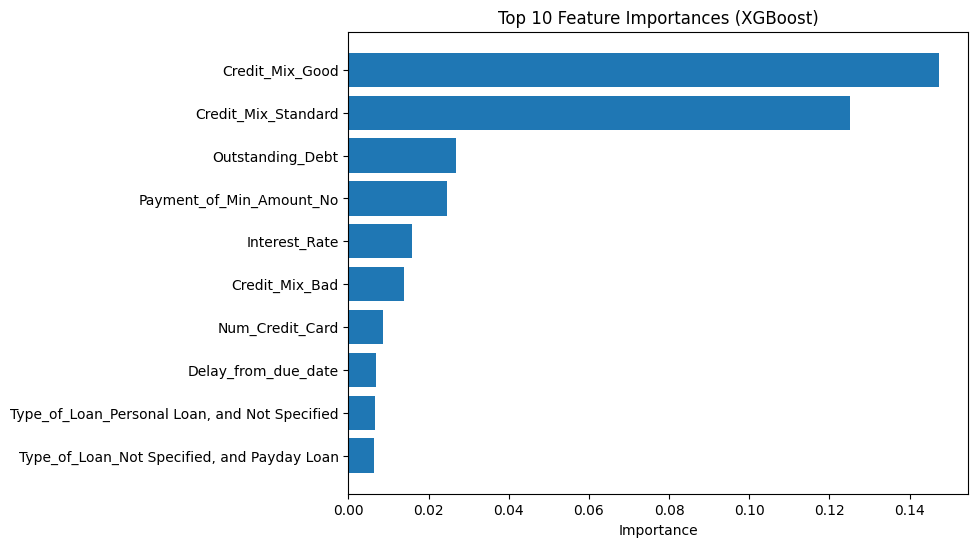

In [67]:
xgb_importances = xgb_best.named_steps["model"].feature_importances_

feature_names_num = num_cols.tolist()
feature_names_cat = xgb_best.named_steps["preprocess"].transformers_[1][1].get_feature_names_out(cat_cols)
feature_names = feature_names_num + feature_names_cat.tolist()

feat_imp_xgb_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False) #sort feature importance dari paling penting
#ke paling tidak, descending

plt.figure(figsize=(8,6))
plt.barh(feat_imp_xgb_df["Feature"][:10][::-1], feat_imp_xgb_df["Importance"][:10][::-1])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

### Kesimpulan Buat Model & Performance

DEFINE
- target y = credit_score, credit score num
- independent x = semua column yang bukan y

ENCODING
- numerical columns --> passed directly into the model
untuk tree based moodels nilai numerical sendiri sudah mempunyai makna --> nilai" tersebut sudah comparable

- Categorical columns --> OneHotEncoder: returns a binary matrix of string or objects
- Menghindari asumsi urutan pada kategori


RANDOM FOREST

3 parameters explicitly defined:
- model n estimators --> berapa trees, lebih banyak lebih stabil tetapi karena sebelum ini daya computational turun (RAM & CPU overload) kita decrease the values
- modex max depth: tree yang shallow rawan underfit
- model min samples split: minimal sample yang dibutuhkan untuk split treenya, lebih sedikit --> lebih banyak splits, complex


XG BOOST
- model yang robust tetapi gampang overfitting

3 parameters explicitly defined:
- n_estimators: jumlah trees, boosting previous mistakes, bisa lebih lama untuk proses
- max_depth: untuk tree complexity, trees yang kecil menangkap general patterns, tetapi trees yang dalam mudah overfitting
- learning_rate: mengatur seberapa banyak setiap tree dapat berkontribusi terhadap correcting, step sizenya, nilai kecil: lama tetapi stabil, nilai besar: cepat tetapi mudah overfitting



MODEL EVALUATION

RANDON FOREST

The Random Forest and XGBoost models had similar predictive performance in classifying crime categories. The Random Forest model has an overall accuracy of 70.16, with weighted precision, recall, and F1-score all around 0.70, showing balanced performance across classes. It performed best on Class 2, which also had the largest support, achieving a recall of 0.77, while performance on Class 0 was weaker, suggesting greater difficulty in correctly identifying minority or less frequent crime categories.

XGBOOST

The XGBoost model slightly outperformed Random Forest (perbandingan dari nilai akurasi dan f1, kecil), achieving an accuracy of 70.49 and a slightly higher weighted precision and F1-score. XGBoost showed improved recall for Class 0 (0.61) and maintained strong performance on Class 2, indicating better handling of class imbalance. Overall, both models show moderate but consistent classification capability, with XGBoost providing a small but meaningful improvement in robustness and class-level balance.


FEATURE IMPORTANCE IN XGBOOST

Analisis feature importance pada model XGBoost menunjukkan bahwa fitur-fitur finansial seperti riwayat kredit, perilaku pembayaran, dan jumlah kredit memiliki kontribusi terbesar dalam memprediksi credit score. Hal ini sejalan dengan konsep domain keuangan, di mana stabilitas pembayaran dan histori kredit menjadi indikator utama dalam penilaian risiko kredit.

Credit_History_Age_Months ~0.21
Fitur paling penting dalam model. Semakin lama riwayat kredit seseorang, semakin besar kepercayaan model terhadap stabilitas finansial individu tersebut.

Outstanding_Debt ~0.17
Jumlah utang yang masih berjalan berpengaruh besar terhadap credit score. Outstanding debt yang tinggi cenderung diasosiasikan dengan risiko kredit yang lebih besar.

Credit_Utilization_Ratio ~0.14
Rasio penggunaan kredit terhadap limit yang tersedia. Nilai rasio yang tinggi menunjukkan ketergantungan terhadap kredit dan berdampak negatif pada credit score.

Num_of_Delayed_Payment ~0.12
Frekuensi keterlambatan pembayaran menjadi indikator kuat perilaku pembayaran yang poor, sehingga berpengaruh signifikan dalam penilaian skor kredit.

Interest_Rate ~0.10
Tingkat bunga yang tinggi sering dikaitkan dengan profil risiko yang lebih tinggi, sehingga menjadi salah satu faktor penting dalam model.